In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
aln = ALNModel()

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln = ALNModel()

aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

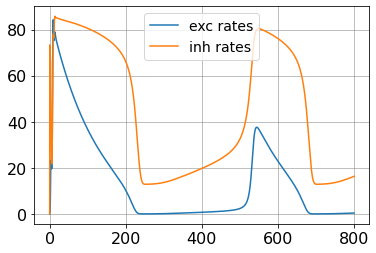

In [4]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

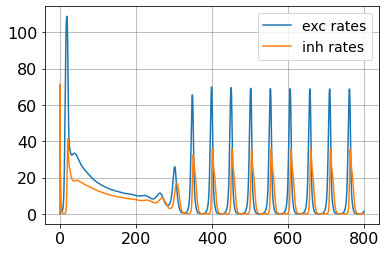

In [5]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

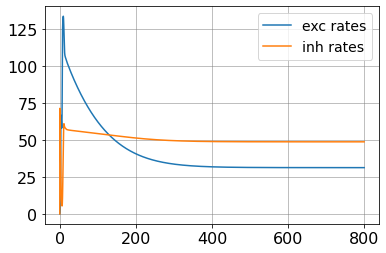

[31.3073 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

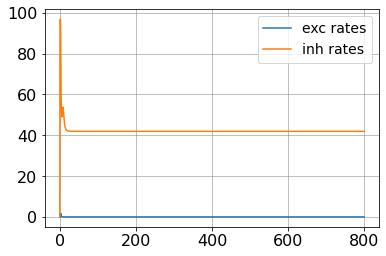

[4.4551e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

### E

In [8]:
dur = 1000
dur_pre = 400
dur_post = 400
aln.params.duration = dur

set_params_fast()

control0 = aln.getZeroControl()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = up_rates[0]
target[:,1,:] = up_rates[1]

tol = 1e-12
start_step = 10.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [9]:
# E.a.1) fast osc => high, max current 1nA, precision only
case = "Ea1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

max_it = 1000

setinit(fast_osc_init)

control0 = aln.getZeroControl()
control0[:,0,:] = 2.5
control0[:,1,:] = 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlEa1[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEa1, bestStateEa1, costEa1, runtimeEa1, gradEa1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEa1 = {"Opt_control": bestControlEa1,
              "Opt_state": bestStateEa1,
              "costArray": costEa1,
              "runtimeArray": runtimeEa1,    
}

dump_dicts = [opt_params, aln.params, resultEa1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  65690.52370585129
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  22100.48182391674
too large start step, decrease to  0.0006103515625
RUN  2 , total integrated cost =  14942.034706011495
too large start step, decrease to  0.0006103515625
too small start step, increase to  0.078125
too large start step, decrease to  0.0006103515625
RUN  3 , total integrated cost =  12657.388772925373
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  4 , total integrated cost =  10592.452031794126
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  5 , total integrated cost =  9141.31592601429
RUN  6 , total integrated cost =  8972.350506183853
RUN  7 , total integrated cost =  8716.366162773658
too large start step, decrease to  0.0006103515

too small start step, increase to  0.078125
RUN  102 , total integrated cost =  3193.379908791363
too large start step, decrease to  0.0006103515625
RUN  103 , total integrated cost =  3193.3200466122435
too small start step, increase to  0.078125
RUN  104 , total integrated cost =  3193.2534525726437
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  105 , total integrated cost =  3193.1841363924295
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  106 , total integrated cost =  3193.1325779382073
too large start step, decrease to  0.0006103515625
RUN  107 , total integrated cost =  3193.087273027999
too small start step, increase to  0.078125
RUN  108 , total integrated cost =  3193.04010191164
RUN  109 , total integrated cost =  3192.9946470664945
RUN  110 , total integrated cost =  3192.9589553202386
RUN  111 , total integrated cost =  3192.924069435477
RUN  112 , total integrated cos

too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  201 , total integrated cost =  3191.0942228081567
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  202 , total integrated cost =  3191.0875842076425
too large start step, decrease to  0.0006103515625
RUN  203 , total integrated cost =  3191.0813431295087
too small start step, increase to  0.078125
RUN  204 , total integrated cost =  3191.0753123356617
too large start step, decrease to  0.0006103515625
RUN  205 , total integrated cost =  3191.0692037528365
too small start step, increase to  0.078125
RUN  206 , total integrated cost =  3191.062763327378
too large start step, decrease to  0.0006103515625
RUN  207 , total integrated cost =  3191.0566396252348
too small start step, increase to  0.078125
RUN  208 , total integrated cost =  3191.049614703313
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0

too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  259 , total integrated cost =  3190.7574549199385
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  260 , total integrated cost =  3190.7527152560347
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  261 , total integrated cost =  3190.747713557514
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  262 , total integrated cost =  3190.743638516048
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  263 , total integrated cost =  3190.7389377569743
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  264 , total integrated cost =  3190.7346926547725
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625


too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  314 , total integrated cost =  3190.551740699646
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  315 , total integrated cost =  3190.5488314933405
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  316 , total integrated cost =  3190.5457419653167
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  317 , total integrated cost =  3190.542503265724
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  318 , total integrated cost =  3190.5398224680794
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  319 , total integrated cost =  3190.5367864779664
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  320 , tot

...

too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  767 , total integrated cost =  3190.3347865513815
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  768 , total integrated cost =  3190.3347636883123
too large start step, decrease to  0.0006103515625
RUN  769 , total integrated cost =  3190.33474282842
too small start step, increase to  0.078125
RUN  770 , total integrated cost =  3190.33471814202
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  771 , total integrated cost =  3190.334694123137
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  772 , total integrated cost =  3190.334660439869
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  773 , total integrated cost =  3190.3346283974215
too small start step, increase to  0.078125


too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  834 , total integrated cost =  3190.3333520635897
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  835 , total integrated cost =  3190.3333287056357
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  836 , total integrated cost =  3190.3332566592026
too large start step, decrease to  0.0006103515625
RUN  837 , total integrated cost =  3190.3331793382745
too small start step, increase to  0.078125
RUN  838 , total integrated cost =  3190.333159957398
RUN  839 , total integrated cost =  3190.3331496616074
RUN  840 , total integrated cost =  3190.333142059359
RUN  841 , total integrated cost =  3190.3331337657387
RUN  842 , total integrated cost =  3190.3331269361565
RUN  843 , total integrated cost =  3190.333119329502
RUN  844 , total integrated cost =  3190.3331125060304
RUN  845 , total integrat

too small start step, increase to  0.078125
RUN  935 , total integrated cost =  3190.332396125917
too large start step, decrease to  0.0006103515625
RUN  936 , total integrated cost =  3190.332388230987
too small start step, increase to  0.078125
RUN  937 , total integrated cost =  3190.332380451857
too large start step, decrease to  0.0006103515625
RUN  938 , total integrated cost =  3190.332373084161
too small start step, increase to  0.078125
RUN  939 , total integrated cost =  3190.33236485039
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  940 , total integrated cost =  3190.332356357124
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  941 , total integrated cost =  3190.3323492978475
too large start step, decrease to  0.0006103515625
RUN  942 , total integrated cost =  3190.332342285877
too small start step, increase to  0.078125
RUN  943 , total integrated cost =  3190.33233400

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


too large start step, decrease to  0.0006103515625
RUN  1000 , total integrated cost =  3190.331938836907
Improved over  1000  iterations by  95.14339092024512  percent.
Problem in initial value trasfer:  Vmean_exc -65.57837794636211 -65.56258244985342
Problem in initial value trasfer:  Vmean_exc -56.65556055829535 -56.65562075953339


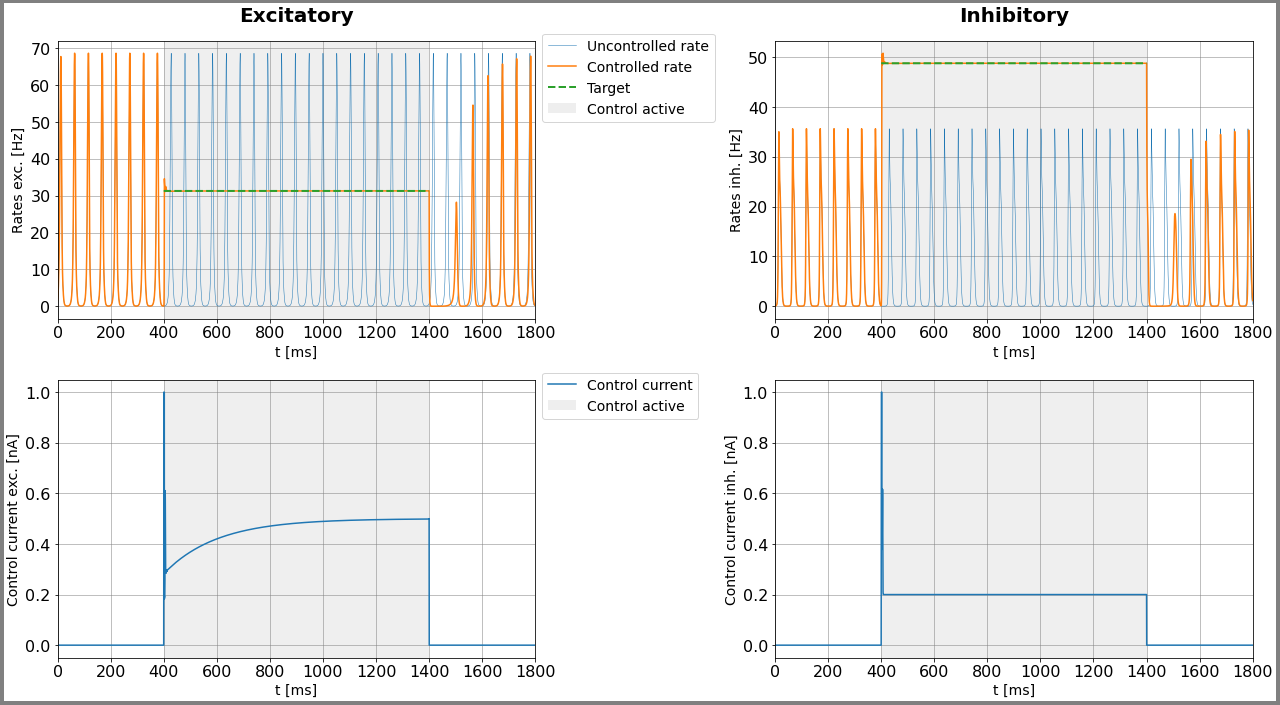

In [10]:
plotFunc.plot_control(aln, bestControlEa1, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

In [11]:
# E.a.2) fast osc => high, max current 1nA, precision + energy + sparsity
case = "Ea2"
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

#max_it = 10

setinit(fast_osc_init)
control0 = aln.getZeroControl()
control0[:,0,:] = 2.5
control0[:,1,:] = 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlEa2[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEa2, bestStateEa2, costEa2, runtimeEa2, gradEa2 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEa2 = {"Opt_control": bestControlEa2,
              "Opt_state": bestStateEa2,
              "costArray": costEa2,
              "runtimeArray": runtimeEa2,    
}

dump_dicts = [opt_params, aln.params, resultEa2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  69426.57145780536
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  25488.469445852847
too large start step, decrease to  0.0006103515625
RUN  2 , total integrated cost =  18273.555965578813
too large start step, decrease to  0.0006103515625
too small start step, increase to  0.078125
too large start step, decrease to  0.0006103515625
RUN  3 , total integrated cost =  15932.281600801894
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  4 , total integrated cost =  14137.382663593951
too large start step, decrease to  0.0006103515625
RUN  5 , total integrated cost =  12716.722718588582
too large start step, decrease to  0.0006103515625
RUN  6 , total integrated cost =  12463.54240255204
too small start step, increase to  0.078125
RUN  7 , total integrated cost =  12180.882565238193

too large start step, decrease to  0.0006103515625
RUN  68 , total integrated cost =  6505.009888236352
too small start step, increase to  0.078125
RUN  69 , total integrated cost =  6505.00343379487
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  70 , total integrated cost =  6504.913861829646
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  71 , total integrated cost =  6504.858456931222
too large start step, decrease to  4.76837158203125e-06
RUN  72 , total integrated cost =  6504.85010945849
too small start step, increase to  0.078125
too small start step, increase to  0.0006103515625
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  73 , total integrated cost =  6504.689196955872
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
too lar

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  101 , total integrated cost =  6503.752199701144
Control only changes marginally.
Improved over  101  iterations by  90.63218582865804  percent.
Problem in initial value trasfer:  Vmean_exc -65.57837794636211 -65.56258244985342
Problem in initial value trasfer:  Vmean_exc -56.652373321201736 -56.64994043355709


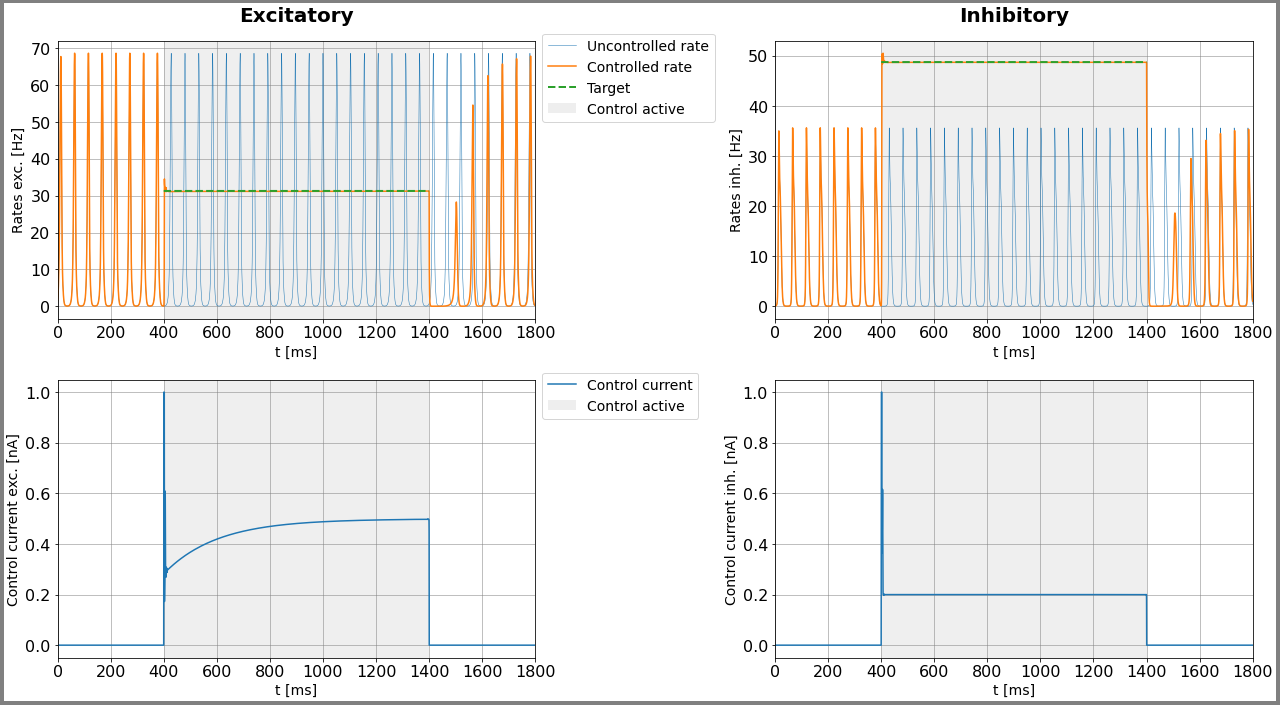

In [12]:
plotFunc.plot_control(aln, bestControlEa2, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

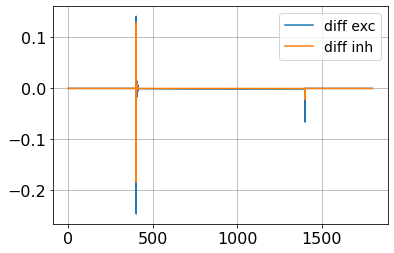

In [13]:
diff = 0.2*(bestControlEa2 - bestControlEa1)

t = np.arange(0, (dur+dur_pre+dur_post+0.1), 0.1)
plt.plot(t, diff[0,0,:], label = "diff exc")
plt.plot(t, diff[0,1,:], label = "diff inh")
plt.legend()
plt.show()

In [14]:
# E.b.1) slow osc => high, max current 1nA, precision only
case = "Eb1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

#max_it = 10

set_params_slow()
setinit(slow_osc_init)

control0 = aln.getZeroControl()
control0[:,0,:] = 1.
control0[:,1,:] = - 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlEa1[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEb1, bestStateEb1, costEb1, runtimeEb1, gradEb1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEb1 = {"Opt_control": bestControlEb1,
              "Opt_state": bestStateEb1,
              "costArray": costEb1,
              "runtimeArray": runtimeEb1,    
}

dump_dicts = [opt_params, aln.params, resultEb1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  72205.84181568566
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  22570.0186111494
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  2 , total integrated cost =  17567.210452804742
RUN  3 , total integrated cost =  14884.311978104066
too large start step, decrease to  0.0006103515625
RUN  4 , total integrated cost =  12971.227122636734
too small start step, increase to  0.078125
RUN  5 , total integrated cost =  10019.31467940844
too large start step, decrease to  0.0006103515625
RUN  6 , total integrated cost =  8246.38777559201
too small start step, increase to  0.078125
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  7 , total integrated cost =  4766.30726045542
too large start step, decrease to  0.0006103515625
too l

RUN  82 , total integrated cost =  993.0952567097148
RUN  83 , total integrated cost =  993.0012727606194
RUN  84 , total integrated cost =  992.9099707664531
RUN  85 , total integrated cost =  992.819172088524
RUN  86 , total integrated cost =  992.7302186466079
RUN  87 , total integrated cost =  992.6421842283186
RUN  88 , total integrated cost =  992.5532098269618
RUN  89 , total integrated cost =  992.4668224911131
RUN  90 , total integrated cost =  992.3821601090233
RUN  91 , total integrated cost =  992.298415950818
RUN  92 , total integrated cost =  992.2151381180411
RUN  93 , total integrated cost =  992.1351962397844
RUN  94 , total integrated cost =  992.0533056527695
RUN  95 , total integrated cost =  991.973875862122
RUN  96 , total integrated cost =  991.894647226568
RUN  97 , total integrated cost =  991.8162984695156
RUN  98 , total integrated cost =  991.7383320567337
RUN  99 , total integrated cost =  991.6643294630024
RUN  100 , total integrated cost =  991.5892196969

RUN  235 , total integrated cost =  988.9075324786984
RUN  236 , total integrated cost =  988.903247886556
RUN  237 , total integrated cost =  988.89901337629
RUN  238 , total integrated cost =  988.8947737698599
RUN  239 , total integrated cost =  988.8906427118095
RUN  240 , total integrated cost =  988.8864643252517
RUN  241 , total integrated cost =  988.8824306425596
RUN  242 , total integrated cost =  988.8783876309504
RUN  243 , total integrated cost =  988.8744556437243
RUN  244 , total integrated cost =  988.8705357277242
RUN  245 , total integrated cost =  988.86664391513
RUN  246 , total integrated cost =  988.8627956703604
RUN  247 , total integrated cost =  988.8589529706331
RUN  248 , total integrated cost =  988.8551764046715
RUN  249 , total integrated cost =  988.8513910685261
RUN  250 , total integrated cost =  988.8476278479467
RUN  251 , total integrated cost =  988.8438035693225
RUN  252 , total integrated cost =  988.8400733377416
RUN  253 , total integrated cost 

RUN  388 , total integrated cost =  988.5158179939236
RUN  389 , total integrated cost =  988.5141559728097
RUN  390 , total integrated cost =  988.5125023823259
RUN  391 , total integrated cost =  988.5108858339825
RUN  392 , total integrated cost =  988.5093298661757
RUN  393 , total integrated cost =  988.5077652917238
RUN  394 , total integrated cost =  988.5061964331078
RUN  395 , total integrated cost =  988.5046724299485
RUN  396 , total integrated cost =  988.5031901980055
RUN  397 , total integrated cost =  988.5017100634009
RUN  398 , total integrated cost =  988.5002121681987
RUN  399 , total integrated cost =  988.4986862690452
RUN  400 , total integrated cost =  988.4971705762273
RUN  401 , total integrated cost =  988.4956930232327
RUN  402 , total integrated cost =  988.4941520326793
RUN  403 , total integrated cost =  988.4925313648213
RUN  404 , total integrated cost =  988.490665753978
RUN  405 , total integrated cost =  988.4889697705677
RUN  406 , total integrated c

RUN  479 , total integrated cost =  988.3498304063307
RUN  480 , total integrated cost =  988.3490149201698
RUN  481 , total integrated cost =  988.3482205271046
RUN  482 , total integrated cost =  988.3474188218688
RUN  483 , total integrated cost =  988.3466229246604
RUN  484 , total integrated cost =  988.345833929801
RUN  485 , total integrated cost =  988.3450594625475
RUN  486 , total integrated cost =  988.3442818851698
RUN  487 , total integrated cost =  988.3435140002766
RUN  488 , total integrated cost =  988.3427334395077
RUN  489 , total integrated cost =  988.3419555480551
RUN  490 , total integrated cost =  988.3411730972604
RUN  491 , total integrated cost =  988.3404080421026
RUN  492 , total integrated cost =  988.3396453227076
RUN  493 , total integrated cost =  988.3388920182343
RUN  494 , total integrated cost =  988.3381347989616
RUN  495 , total integrated cost =  988.3373792667456
RUN  496 , total integrated cost =  988.3366118490006
RUN  497 , total integrated c

RUN  632 , total integrated cost =  988.2525151657348
RUN  633 , total integrated cost =  988.2520163644116
RUN  634 , total integrated cost =  988.2515238879683
RUN  635 , total integrated cost =  988.251038688728
RUN  636 , total integrated cost =  988.2505522206916
RUN  637 , total integrated cost =  988.2500708932524
RUN  638 , total integrated cost =  988.2495855946854
RUN  639 , total integrated cost =  988.2491045215077
RUN  640 , total integrated cost =  988.2486107873632
RUN  641 , total integrated cost =  988.2481283084796
RUN  642 , total integrated cost =  988.2476424244463
RUN  643 , total integrated cost =  988.2471582347276
RUN  644 , total integrated cost =  988.2466793369616
RUN  645 , total integrated cost =  988.246207843397
RUN  646 , total integrated cost =  988.2457351319936
RUN  647 , total integrated cost =  988.2452673681126
RUN  648 , total integrated cost =  988.2447953872907
RUN  649 , total integrated cost =  988.2443282679247
RUN  650 , total integrated co

RUN  785 , total integrated cost =  988.1906050339512
RUN  786 , total integrated cost =  988.1902799741081
RUN  787 , total integrated cost =  988.1899528502885
RUN  788 , total integrated cost =  988.1896313977337
RUN  789 , total integrated cost =  988.1893137927666
RUN  790 , total integrated cost =  988.1889954350146
RUN  791 , total integrated cost =  988.1886801791877
RUN  792 , total integrated cost =  988.188362988783
RUN  793 , total integrated cost =  988.1880470209395
RUN  794 , total integrated cost =  988.1877245343361
RUN  795 , total integrated cost =  988.1874073816032
RUN  796 , total integrated cost =  988.1870898714226
RUN  797 , total integrated cost =  988.1867713308485
RUN  798 , total integrated cost =  988.1864576234401
RUN  799 , total integrated cost =  988.1861479493375
RUN  800 , total integrated cost =  988.1858375483774
RUN  801 , total integrated cost =  988.1855301450352
RUN  802 , total integrated cost =  988.1852205621536
RUN  803 , total integrated c

RUN  938 , total integrated cost =  988.1476976272099
RUN  939 , total integrated cost =  988.1474511355079
RUN  940 , total integrated cost =  988.147223150864
RUN  941 , total integrated cost =  988.1469868862448
RUN  942 , total integrated cost =  988.146754138115
RUN  943 , total integrated cost =  988.1465254002279
RUN  944 , total integrated cost =  988.1462881019822
RUN  945 , total integrated cost =  988.1460407156196
RUN  946 , total integrated cost =  988.1458212014863
RUN  947 , total integrated cost =  988.1456055575219
RUN  948 , total integrated cost =  988.1453883318281
RUN  949 , total integrated cost =  988.1451486415701
RUN  950 , total integrated cost =  988.1449252192418
RUN  951 , total integrated cost =  988.1446956422261
RUN  952 , total integrated cost =  988.144467530231
RUN  953 , total integrated cost =  988.1442452973185
RUN  954 , total integrated cost =  988.1440121653739
RUN  955 , total integrated cost =  988.143772108931
RUN  956 , total integrated cost

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  988.1347159465835
Improved over  1000  iterations by  98.6315030874248  percent.
Problem in initial value trasfer:  Vmean_exc -64.15862114686198 -64.15339522176708
Problem in initial value trasfer:  Vmean_exc -56.65556192717463 -56.65562933441584


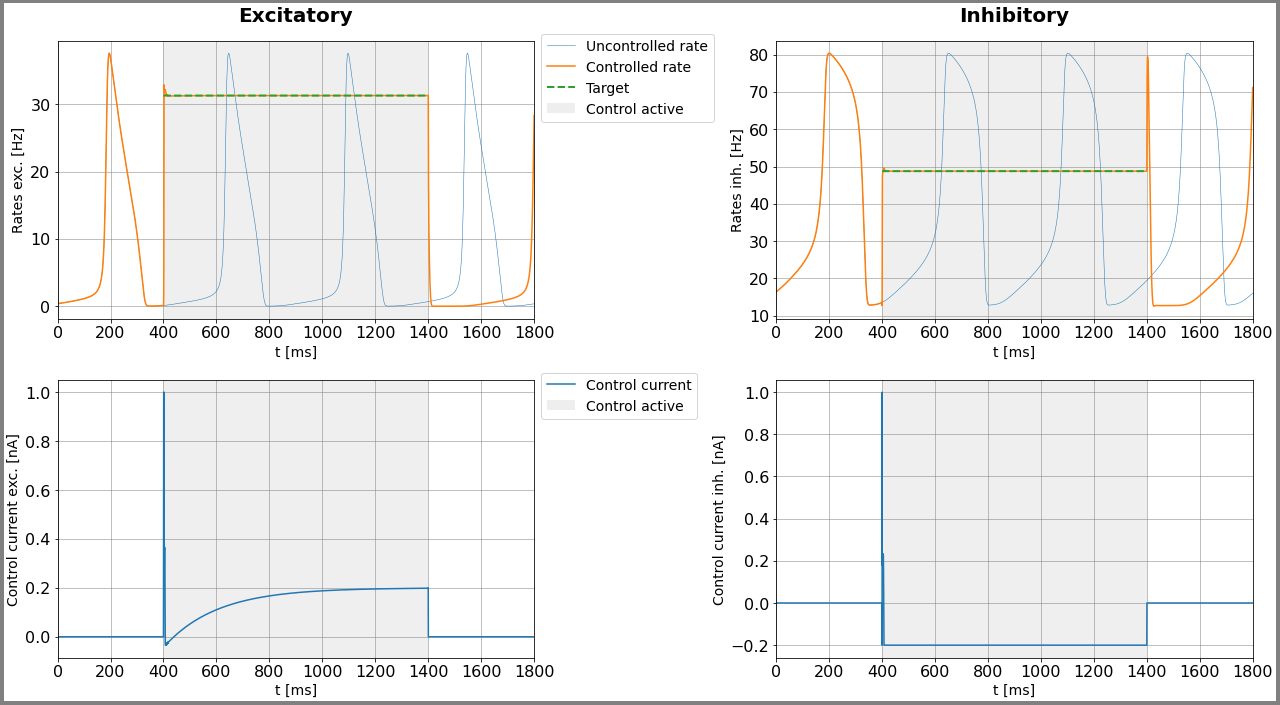

In [15]:
plotFunc.plot_control(aln, bestControlEb1, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )

In [16]:
# E.b.2) slow osc => high, max current 1nA, precision + energy + sparsity
case = "Eb2"
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

#max_it = 10

setinit(slow_osc_init)
control0 = aln.getZeroControl()
control0[:,0,:] = 1.
control0[:,1,:] = - 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlEa2[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEb2, bestStateEb2, costEb2, runtimeEb2, gradEb2 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEb2 = {"Opt_control": bestControlEb2,
              "Opt_state": bestStateEb2,
              "costArray": costEb2,
              "runtimeArray": runtimeEb2,    
}

dump_dicts = [opt_params, aln.params, resultEb2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  73269.19053108728
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  23521.73149201162
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  2 , total integrated cost =  18493.69284227926
RUN  3 , total integrated cost =  15788.830295359276
too large start step, decrease to  0.0006103515625
RUN  4 , total integrated cost =  13873.571353126725
too small start step, increase to  0.078125
RUN  5 , total integrated cost =  10881.986632825681
too large start step, decrease to  0.0006103515625
RUN  6 , total integrated cost =  9126.904437046185
too small start step, increase to  0.078125
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  7 , total integrated cost =  5643.40723118293
too large start step, decrease to  0.0006103515625
too

too small start step, increase to  0.078125
RUN  68 , total integrated cost =  1914.891679178227
RUN  69 , total integrated cost =  1914.8186757333538
RUN  70 , total integrated cost =  1914.796388571075
RUN  71 , total integrated cost =  1914.7467976263267
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  72 , total integrated cost =  1914.7139036806875
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  73 , total integrated cost =  1914.6258035611963
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  74 , total integrated cost =  1914.5578588687736
too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  75 , total integrated cost =  1914.5117018672518
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  76 , total integrated cost =  1914.4909

too small start step, increase to  0.078125
too small start step, increase to  0.078125
RUN  146 , total integrated cost =  1913.4046203958665
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  147 , total integrated cost =  1913.402542169048
RUN  148 , total integrated cost =  1913.3992421665048
RUN  149 , total integrated cost =  1913.3958182823992
RUN  150 , total integrated cost =  1913.3937277538055
RUN  151 , total integrated cost =  1913.3913877141067
too large start step, decrease to  4.76837158203125e-06
RUN  152 , total integrated cost =  1913.3890111532214
too small start step, increase to  0.0006103515625
RUN  153 , total integrated cost =  1913.3867384692321
too large start step, decrease to  4.76837158203125e-06
RUN  154 , total integrated cost =  1913.3845404143335
too small start step, increase to  0.0006103515625
RUN  155 , total integrated cost =  1913.3822975974986
too large start step, decrease to  4.7683715820

RUN  234 , total integrated cost =  1913.2673627012775
RUN  235 , total integrated cost =  1913.266758680098
too large start step, decrease to  4.76837158203125e-06
RUN  236 , total integrated cost =  1913.2661497908587
too small start step, increase to  0.0006103515625
RUN  237 , total integrated cost =  1913.2655439936636
RUN  238 , total integrated cost =  1913.2649916397095
RUN  239 , total integrated cost =  1913.264422935961
RUN  240 , total integrated cost =  1913.2638815680768
RUN  241 , total integrated cost =  1913.2633334997468
RUN  242 , total integrated cost =  1913.2628099886178
RUN  243 , total integrated cost =  1913.2622738518746
RUN  244 , total integrated cost =  1913.2617732864176
RUN  245 , total integrated cost =  1913.2612427587833
RUN  246 , total integrated cost =  1913.260763164953
RUN  247 , total integrated cost =  1913.260215864689
too large start step, decrease to  4.76837158203125e-06
RUN  248 , total integrated cost =  1913.2597760309561
too small start 

too large start step, decrease to  4.76837158203125e-06
RUN  311 , total integrated cost =  1913.2328938202172
too small start step, increase to  0.0006103515625
RUN  312 , total integrated cost =  1913.2327167472185
too large start step, decrease to  4.76837158203125e-06
RUN  313 , total integrated cost =  1913.2324374258965
too small start step, increase to  0.0006103515625
RUN  314 , total integrated cost =  1913.2321823471236
too large start step, decrease to  4.76837158203125e-06
RUN  315 , total integrated cost =  1913.2316554347694
too small start step, increase to  0.0006103515625
RUN  316 , total integrated cost =  1913.231158955041
too large start step, decrease to  4.76837158203125e-06
RUN  317 , total integrated cost =  1913.2305986848437
too small start step, increase to  2.2737367544323206e-12
too small start step, increase to  2.9103830456733704e-10
too small start step, increase to  3.725290298461914e-08
too small start step, increase to  4.76837158203125e-06
too small 

too small start step, increase to  2.9103830456733704e-10
RUN  370 , total integrated cost =  1913.2014545468119
RUN  371 , total integrated cost =  1913.2014518753108
too large start step, decrease to  2.2737367544323206e-12
too large start step, decrease to  2.2737367544323206e-12
RUN  372 , total integrated cost =  1913.2014120501053
too large start step, decrease to  1.7763568394002505e-14
too large start step, decrease to  1.7763568394002505e-14
RUN  373 , total integrated cost =  1913.2013992081693
RUN  374 , total integrated cost =  1913.2013947369321
too small start step, increase to  2.2737367544323206e-12
too small start step, increase to  2.9103830456733704e-10
RUN  375 , total integrated cost =  1913.2013252270724
too small start step, increase to  2.2737367544323206e-12
too large start step, decrease to  2.2737367544323206e-12
RUN  376 , total integrated cost =  1913.2012943395644
too large start step, decrease to  1.7763568394002505e-14
too large start step, decrease to  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  431 , total integrated cost =  1913.2001616598056
Control only changes marginally.
Improved over  431  iterations by  97.38880674429171  percent.
Problem in initial value trasfer:  Vmean_exc -64.15862114686198 -64.15339522176708
Problem in initial value trasfer:  Vmean_exc -56.65406620673508 -56.65244576623883


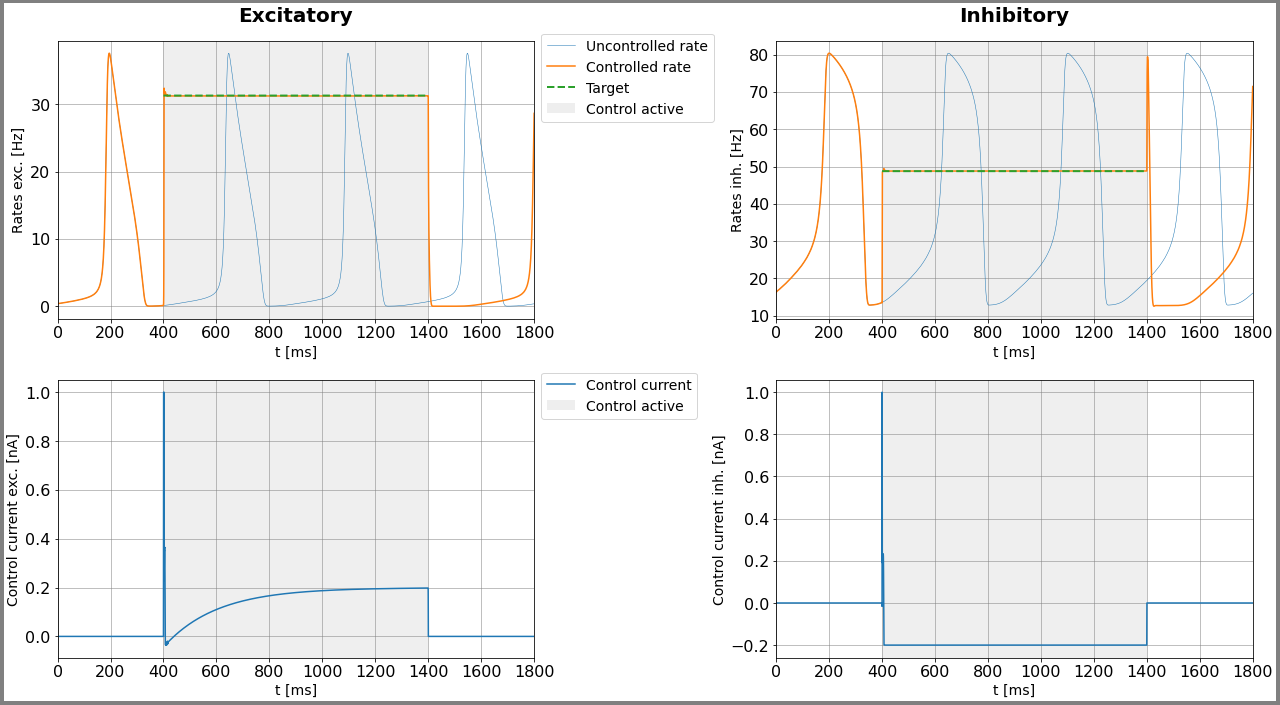

In [17]:
plotFunc.plot_control(aln, bestControlEb2, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )

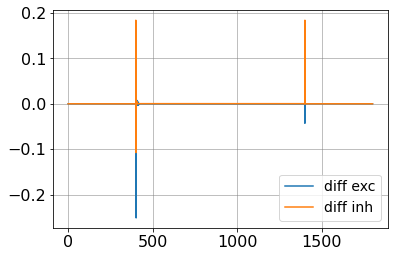

In [18]:
diff = 0.2*(bestControlEb2 - bestControlEb1)

t = np.arange(0, (dur+dur_pre+dur_post+0.1), 0.1)
plt.plot(t, diff[0,0,:], label = "diff exc")
plt.plot(t, diff[0,1,:], label = "diff inh")
plt.legend()
plt.show()